# 의왕시 교통안전 시각화 분석 (업데이트 반영)
최신 데이터 폴더(`데이터_정리`) 기준으로 로드/전처리와 시각화를 갱신했습니다.
- 셀 2: 데이터 로드/전처리
- 셀 3~7: 기존 시각화(최신 경로 반영)
- 셀 8~10: 신규 시각화(후보지 구성, 의왕 지표 비교, 데이터 정합성 요약)

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# ── 한글 폰트 설정 ──
FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
if Path(FONT_PATH).exists():
    fm.fontManager.addfont(FONT_PATH)
    font_prop = fm.FontProperties(fname=FONT_PATH)
    FONT_NAME = font_prop.get_name()
else:
    FONT_NAME = 'Malgun Gothic'

sns.set_theme(style='whitegrid', rc={
    'font.family': FONT_NAME,
    'axes.unicode_minus': False,
    'figure.dpi': 120,
})

def fix_korean_font(fig):
    for text_obj in fig.findobj(plt.Text):
        text_obj.set_fontfamily(FONT_NAME)

print('적용 폰트:', FONT_NAME)

base = Path(r"C:/Users/USER/Desktop/김민우(현장실습생)/second report")
data_root = base / '데이터_정리'
processed = data_root / '02_가공데이터'
qgis_csv = processed / 'qgis_ready' / 'csv'
cleaned = data_root / '03_정리데이터'

# 경기 시군구 사고/인구/세대/면적 통합 지표(정리본)
gyeonggi = pd.read_csv(cleaned / '09_경기_시군구별_교통사고_면적인구세대대비비율.csv', encoding='utf-8-sig')
gyeonggi = gyeonggi[gyeonggi['시도'] == '경기'].copy()
gyeonggi = gyeonggi[~gyeonggi['시군구'].astype(str).str.contains('합계', na=False)]
gyeonggi = gyeonggi.dropna(subset=['사고(건)']).copy()
uiwang_row = gyeonggi[gyeonggi['시군구'] == '의왕시'].copy()

# CCTV 개수/비율(정리본)
cctv_count = pd.read_csv(cleaned / '05_경기도_행정구역별_CCTV개수.csv', encoding='utf-8-sig')
cctv_count['CCTV개수'] = pd.to_numeric(cctv_count['CCTV개수'], errors='coerce')
cctv_ratio = pd.read_csv(cleaned / '06_경기도_지역별_면적인구세대대비_CCTV비율.csv', encoding='utf-8-sig')
for col in ['면적당_CCTV(대/㎢)', '인구1만명당_CCTV(대)']:
    cctv_ratio[col] = pd.to_numeric(cctv_ratio[col], errors='coerce')

# 사망교통사고(의왕시, 좌표 정리본)
fatal = pd.read_csv(qgis_csv / 'fatal_accidents_uiwang.csv', encoding='utf-8-sig')
fatal = fatal[fatal['시군명'] == '의왕시'].copy()
fatal['위도'] = pd.to_numeric(fatal['위도'], errors='coerce')
fatal['경도'] = pd.to_numeric(fatal['경도'], errors='coerce')
fatal = fatal.dropna(subset=['위도', '경도'])

# requirement 산출물(최신 가공 데이터)
traffic_cctv = pd.read_csv(processed / 'traffic_cctv_uiwang.csv', encoding='utf-8-sig')
hotspots = pd.read_csv(processed / 'accident_hotspots.csv', encoding='utf-8-sig')
bus_stop = pd.read_csv(processed / 'bus_stop_uiwang.csv', encoding='utf-8-sig')
candidates = pd.read_csv(processed / 'cctv_candidate_locations.csv', encoding='utf-8-sig')
comparison_summary = pd.read_csv(processed / 'comparison_summary_의왕_vs_CCTV교통단속.csv', encoding='utf-8-sig')
run_summary = pd.read_csv(processed / 'requirement_run_summary.csv', encoding='utf-8-sig')

# 숫자형 컬럼 정규화
for df_name, df_obj in [
    ('traffic_cctv', traffic_cctv),
    ('hotspots', hotspots),
    ('bus_stop', bus_stop),
    ('candidates', candidates),
]:
    if '위도' in df_obj.columns:
        df_obj['위도'] = pd.to_numeric(df_obj['위도'], errors='coerce')
    if '경도' in df_obj.columns:
        df_obj['경도'] = pd.to_numeric(df_obj['경도'], errors='coerce')

traffic_cctv = traffic_cctv.dropna(subset=['위도', '경도'])
hotspots = hotspots.dropna(subset=['위도', '경도'])
bus_stop = bus_stop.dropna(subset=['위도', '경도'])
candidates = candidates.dropna(subset=['위도', '경도'])

print('경기 시군구 수:', len(gyeonggi))
print('CCTV 개수 테이블 수:', len(cctv_count))
print('CCTV 비율 테이블 수:', len(cctv_ratio))
print('교통단속 CCTV 수:', len(traffic_cctv))
print('핫스팟 수:', len(hotspots))
print('의왕시 버스정류소 수:', len(bus_stop))
print('후보지 수:', len(candidates))

적용 폰트: Malgun Gothic
경기 시군구 수: 31
CCTV 개수 테이블 수: 31
CCTV 비율 테이블 수: 31
교통단속 CCTV 수: 15
핫스팟 수: 66
의왕시 버스정류소 수: 389
후보지 수: 852


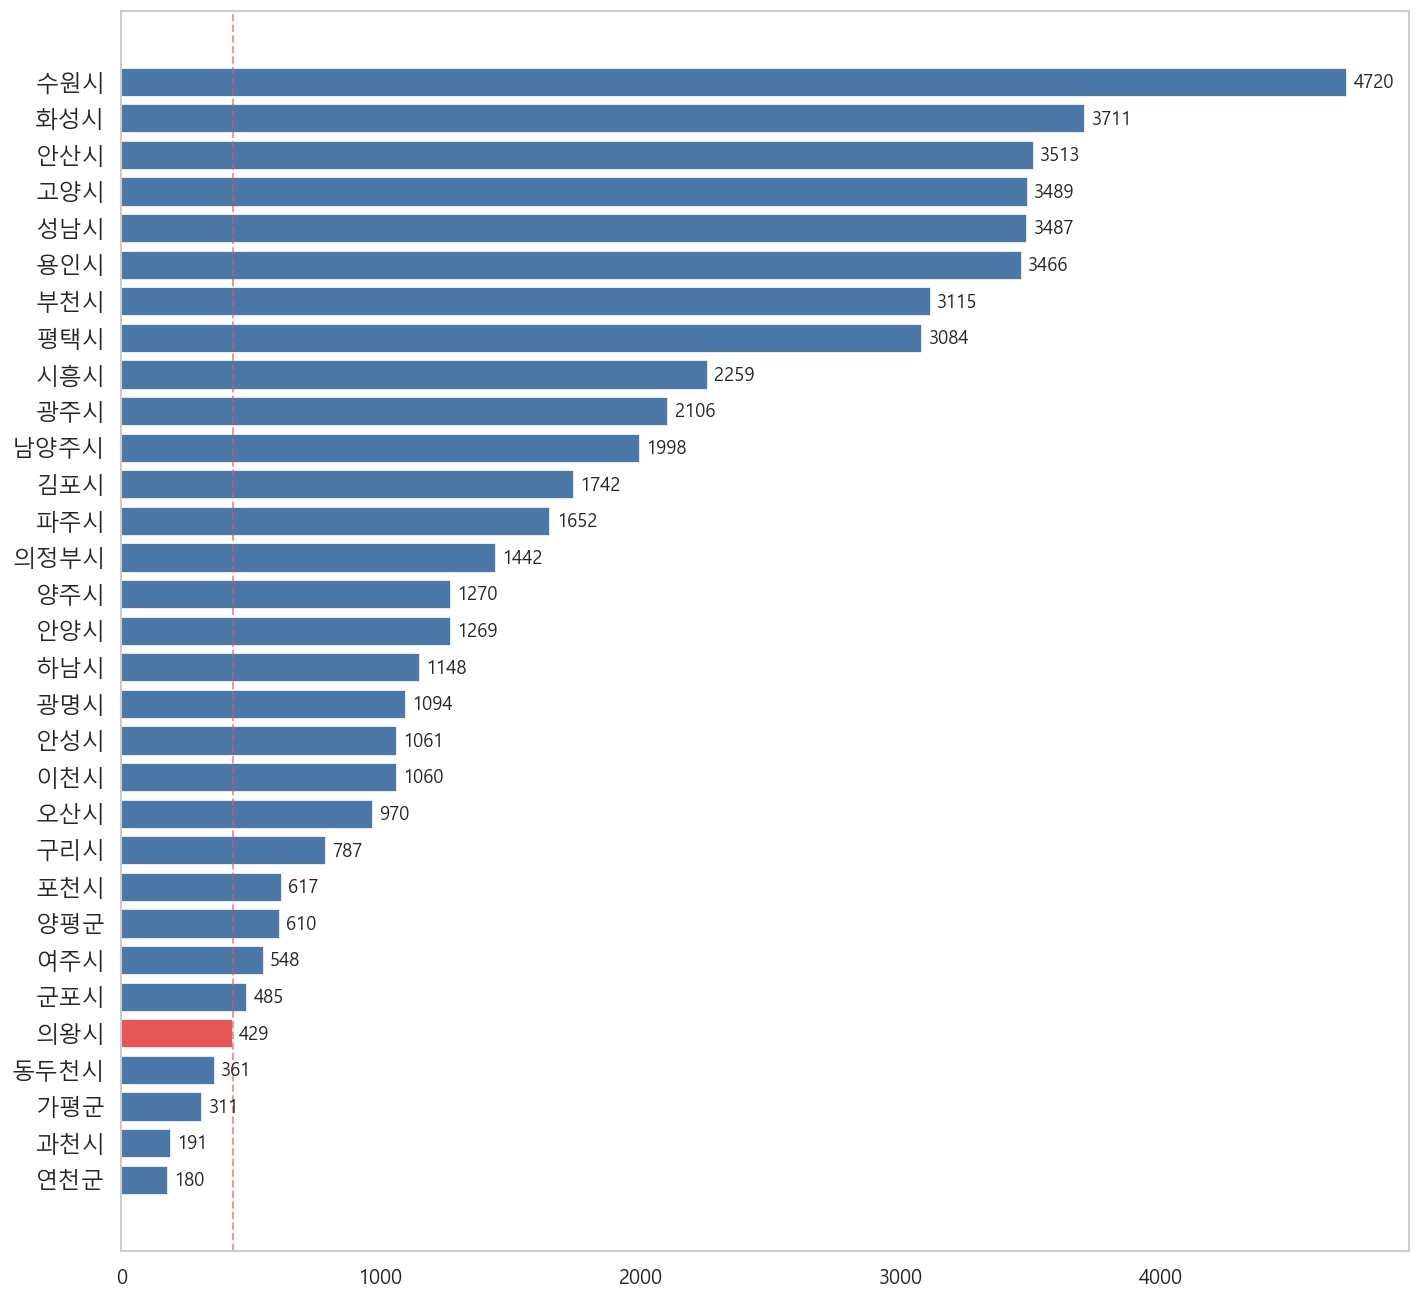

In [102]:
# 시각화 1-추가: 2024년 경기 전체 시군구 사고(건) 비교
all_compare = gyeonggi[['시군구', '사고(건)']].copy().sort_values('사고(건)', ascending=True)
all_compare['사고(건)'] = pd.to_numeric(all_compare['사고(건)'], errors='coerce')

bar_colors = ['#4C78A8' if name != '의왕시' else '#E45756' for name in all_compare['시군구']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(all_compare['시군구'], all_compare['사고(건)'], color=bar_colors)
# ax.set_title('2024년 경기 전체 시군구 사고(건) 비교', fontsize=16, fontweight='bold')
# ax.set_xlabel('사고(건)', fontsize=14)
# ax.set_ylabel('시군구', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.grid(False)

uiwang_val = all_compare.loc[all_compare['시군구'] == '의왕시', '사고(건)']
if not uiwang_val.empty:
    ax.axvline(float(uiwang_val.iloc[0]), color='#E45756', linestyle='--', linewidth=1.2, alpha=0.6)

for y, val in enumerate(all_compare['사고(건)']):
    ax.text(val + all_compare['사고(건)'].max() * 0.005, y, f'{int(val)}', va='center', fontsize=11)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

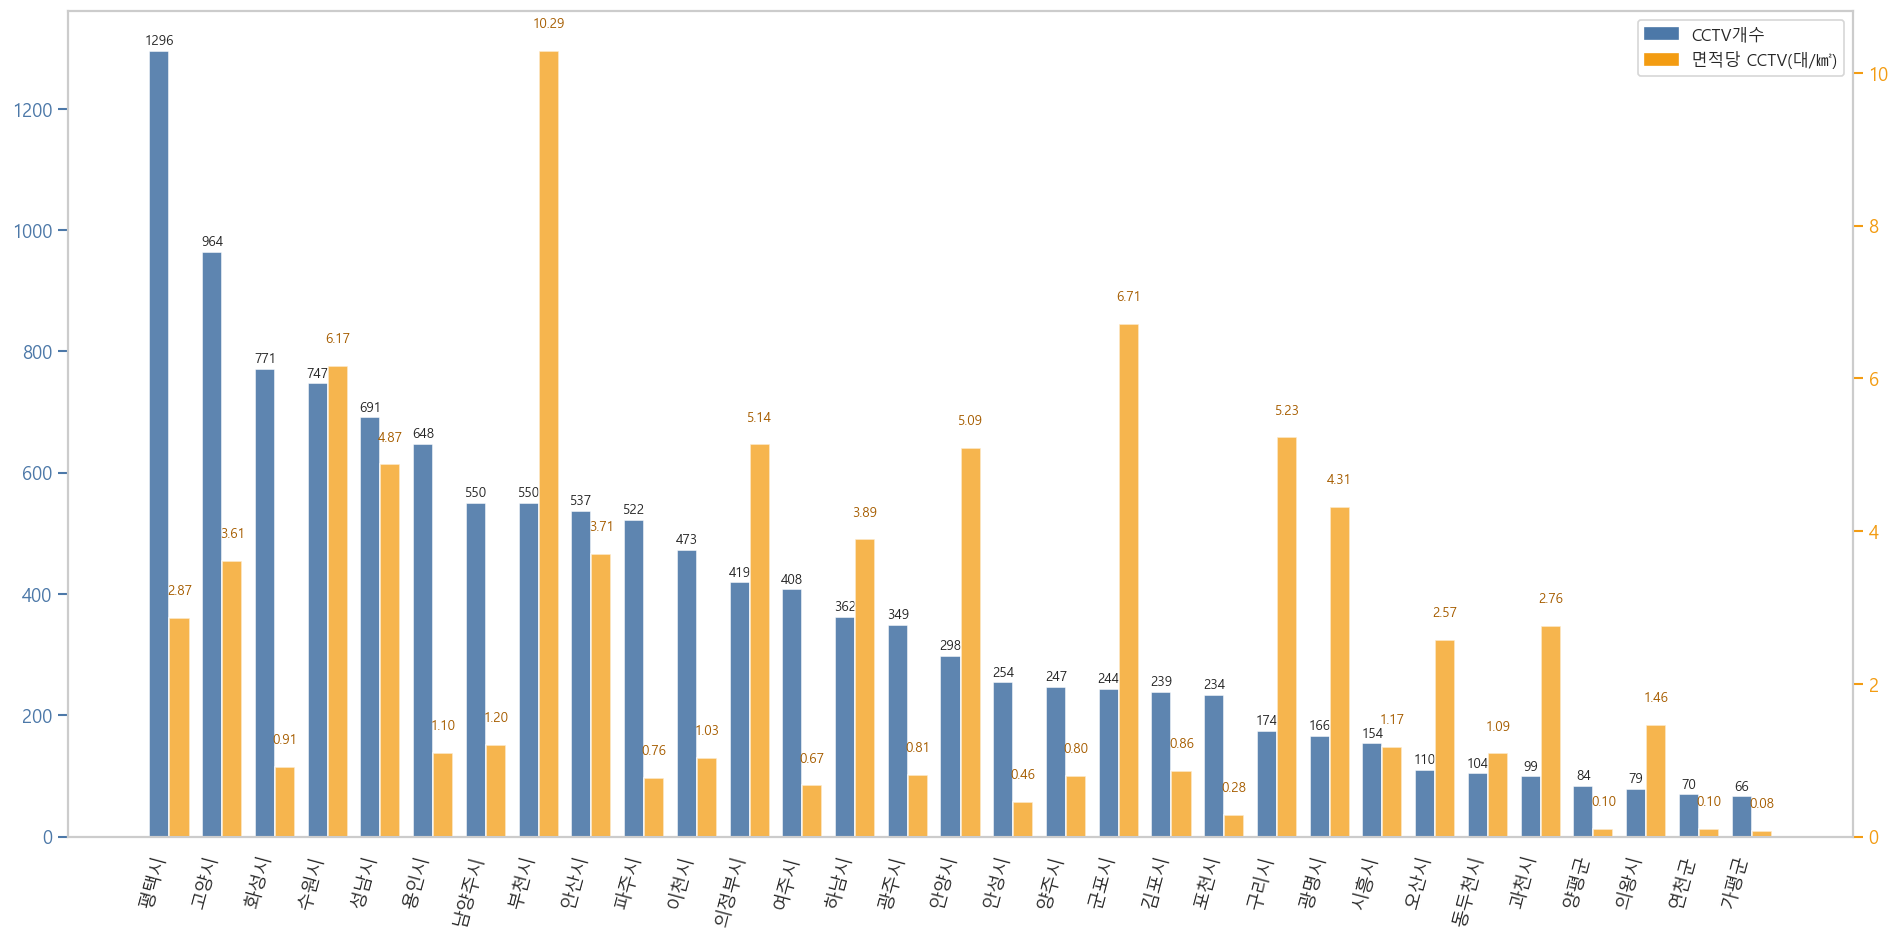

In [117]:
# 시각화 1-추가2: 지역별 CCTV개수 + 면적당 CCTV 비율(세로 그룹 막대)
cctv_compare = cctv_count[['지역', 'CCTV개수']].dropna().copy()
area_ratio = cctv_ratio[['지역', '면적당_CCTV(대/㎢)']].dropna().copy()
merged = cctv_compare.merge(area_ratio, on='지역', how='left')
merged = merged.sort_values('CCTV개수', ascending=False).reset_index(drop=True)

x = np.arange(len(merged))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 8))
bars1 = ax.bar(
    x - w / 2,
    merged['CCTV개수'],
    width=w,
    color='#4C78A8',
    alpha=0.9,
    label='CCTV개수',
)

# 보조축(우측 y축)에 면적당 CCTV 비율 막대
ax2 = ax.twinx()
bars2 = ax2.bar(
    x + w / 2,
    merged['면적당_CCTV(대/㎢)'],
    width=w,
    color='#F39C12',
    alpha=0.75,
    label='면적당 CCTV(대/㎢)',
)

# ax.set_title('지역별 CCTV개수 + 면적당 CCTV 비율(세로 그룹 막대)', fontsize=16, fontweight='bold')
# ax.set_xlabel('시군구', fontsize=13)
# ax.set_ylabel('CCTV개수', fontsize=13)
# ax2.set_ylabel('면적당 CCTV(대/㎢)', fontsize=13, color='#F39C12')

ax.set_xticks(x)
ax.set_xticklabels(merged['지역'], rotation=75, ha='right')
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11, colors='#4C78A8')
ax2.tick_params(axis='y', labelsize=11, colors='#F39C12')
ax.grid(False)
ax2.grid(False)

for i, val in enumerate(merged['CCTV개수']):
    ax.text(i - w / 2, val + merged['CCTV개수'].max() * 0.008, f'{int(val)}', ha='center', fontsize=8)
for i, val in enumerate(merged['면적당_CCTV(대/㎢)']):
    ax2.text(i + w / 2, val + merged['면적당_CCTV(대/㎢)'].max() * 0.03, f'{val:.2f}', ha='center', fontsize=8, color='#A65D00')

from matplotlib.patches import Patch
legend_handles = [Patch(color='#4C78A8', label='CCTV개수'), Patch(color='#F39C12', label='면적당 CCTV(대/㎢)')]
ax.legend(handles=legend_handles, loc='upper right', fontsize=10, frameon=True)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

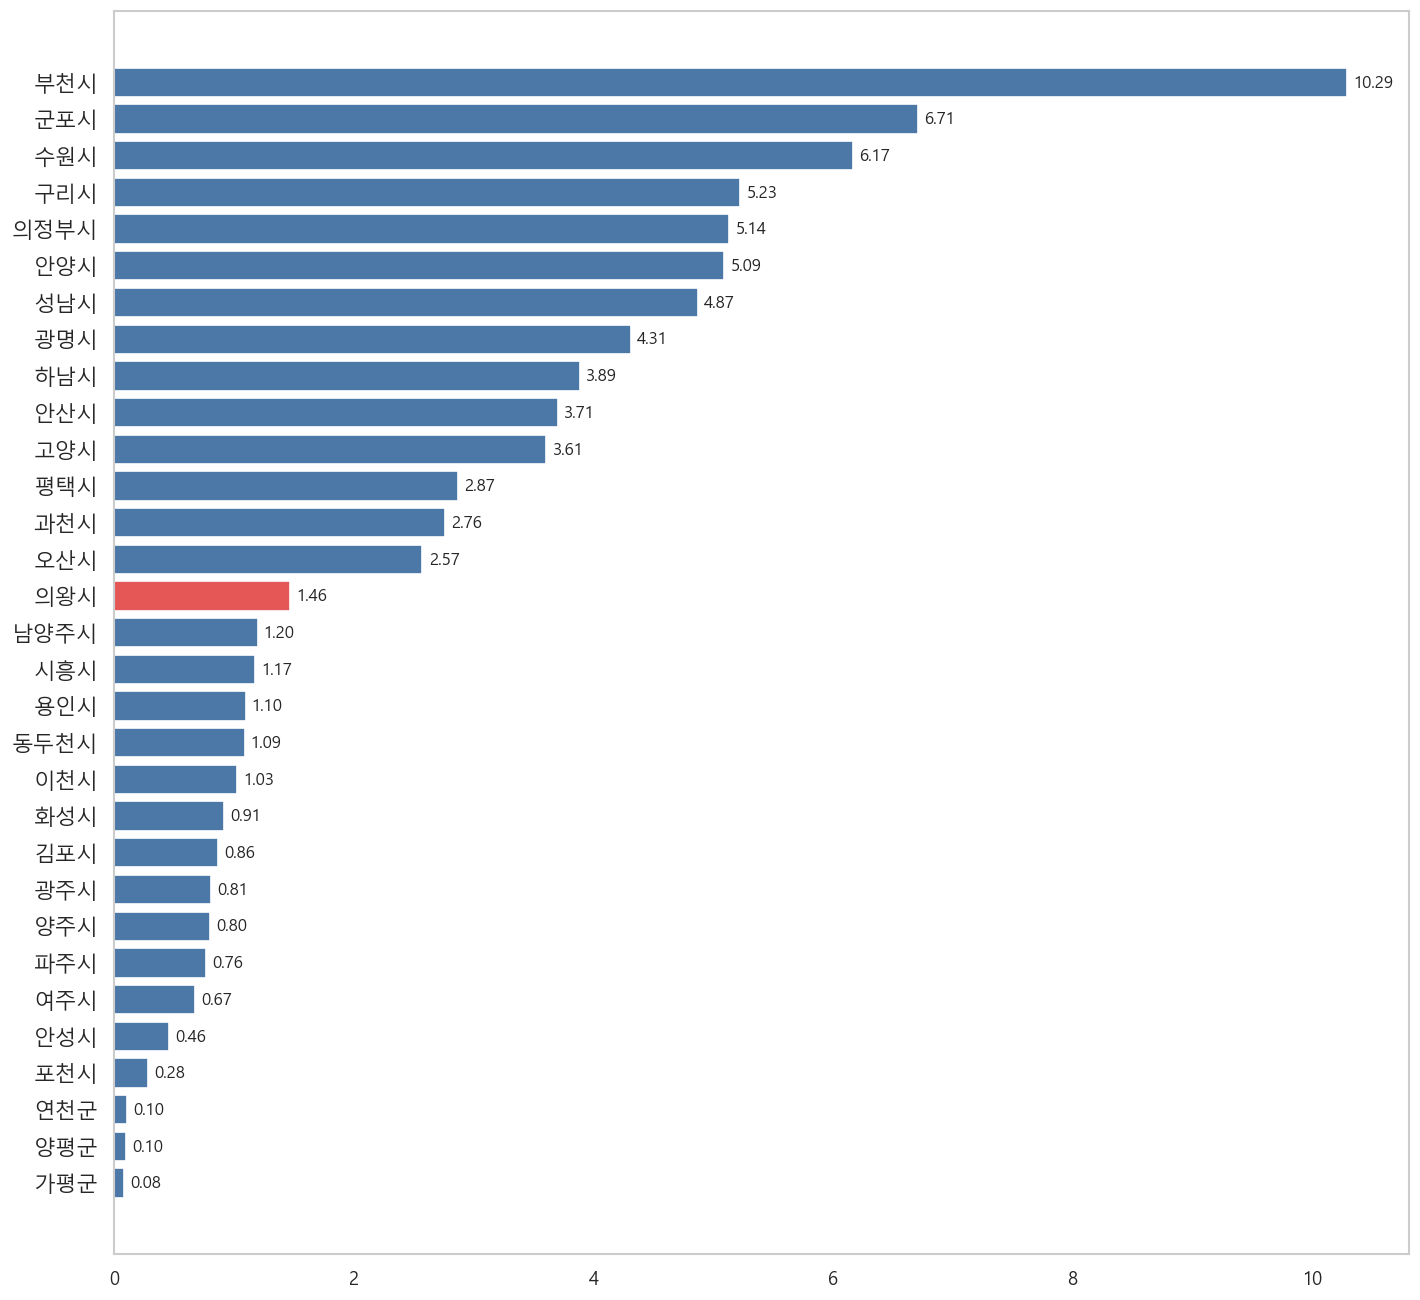

In [104]:
# 시각화 1-확장A: 경기 시군구 면적당 CCTV(대/㎢) 순위
rank_area_cctv = cctv_ratio[['지역', '면적당_CCTV(대/㎢)']].dropna().copy()
rank_area_cctv = rank_area_cctv.sort_values('면적당_CCTV(대/㎢)', ascending=True)

colors = ['#4C78A8' if x != '의왕시' else '#E45756' for x in rank_area_cctv['지역']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(rank_area_cctv['지역'], rank_area_cctv['면적당_CCTV(대/㎢)'], color=colors)
# ax.set_title('경기 시군구 면적당 CCTV(대/㎢) 순위', fontsize=15, fontweight='bold')
# ax.set_xlabel('면적당 CCTV(대/㎢)', fontsize=13)
# ax.set_ylabel('시군구', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

for y, val in enumerate(rank_area_cctv['면적당_CCTV(대/㎢)']):
    ax.text(val + rank_area_cctv['면적당_CCTV(대/㎢)'].max() * 0.005, y, f'{val:.2f}', va='center', fontsize=10)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

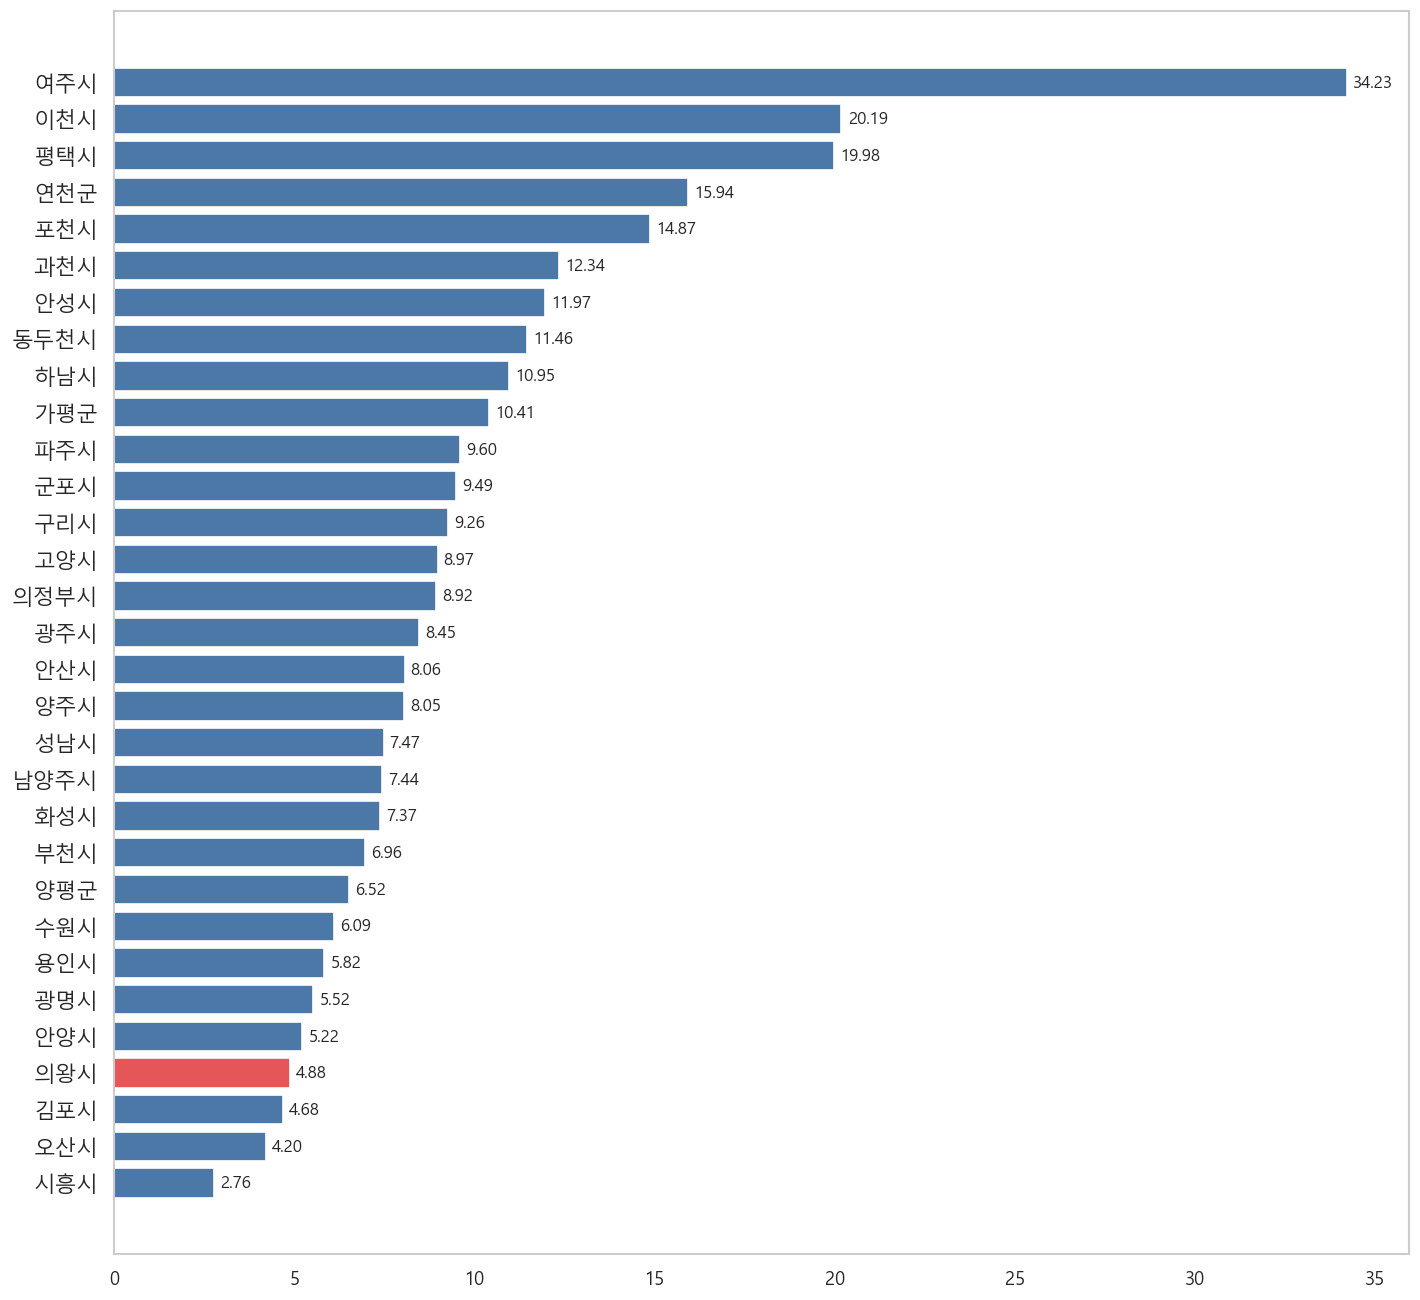

In [105]:
# 시각화 1-확장B: 경기 시군구 인구 1만명당 CCTV(대) 순위
rank_pop_cctv = cctv_ratio[['지역', '인구1만명당_CCTV(대)']].dropna().copy()
rank_pop_cctv = rank_pop_cctv.sort_values('인구1만명당_CCTV(대)', ascending=True)

colors = ['#4C78A8' if x != '의왕시' else '#E45756' for x in rank_pop_cctv['지역']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(rank_pop_cctv['지역'], rank_pop_cctv['인구1만명당_CCTV(대)'], color=colors)
# ax.set_title('경기 시군구 인구 1만명당 CCTV(대) 순위', fontsize=15, fontweight='bold')
# ax.set_xlabel('인구 1만명당 CCTV(대)', fontsize=13)
# ax.set_ylabel('시군구', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

for y, val in enumerate(rank_pop_cctv['인구1만명당_CCTV(대)']):
    ax.text(val + rank_pop_cctv['인구1만명당_CCTV(대)'].max() * 0.005, y, f'{val:.2f}', va='center', fontsize=10)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

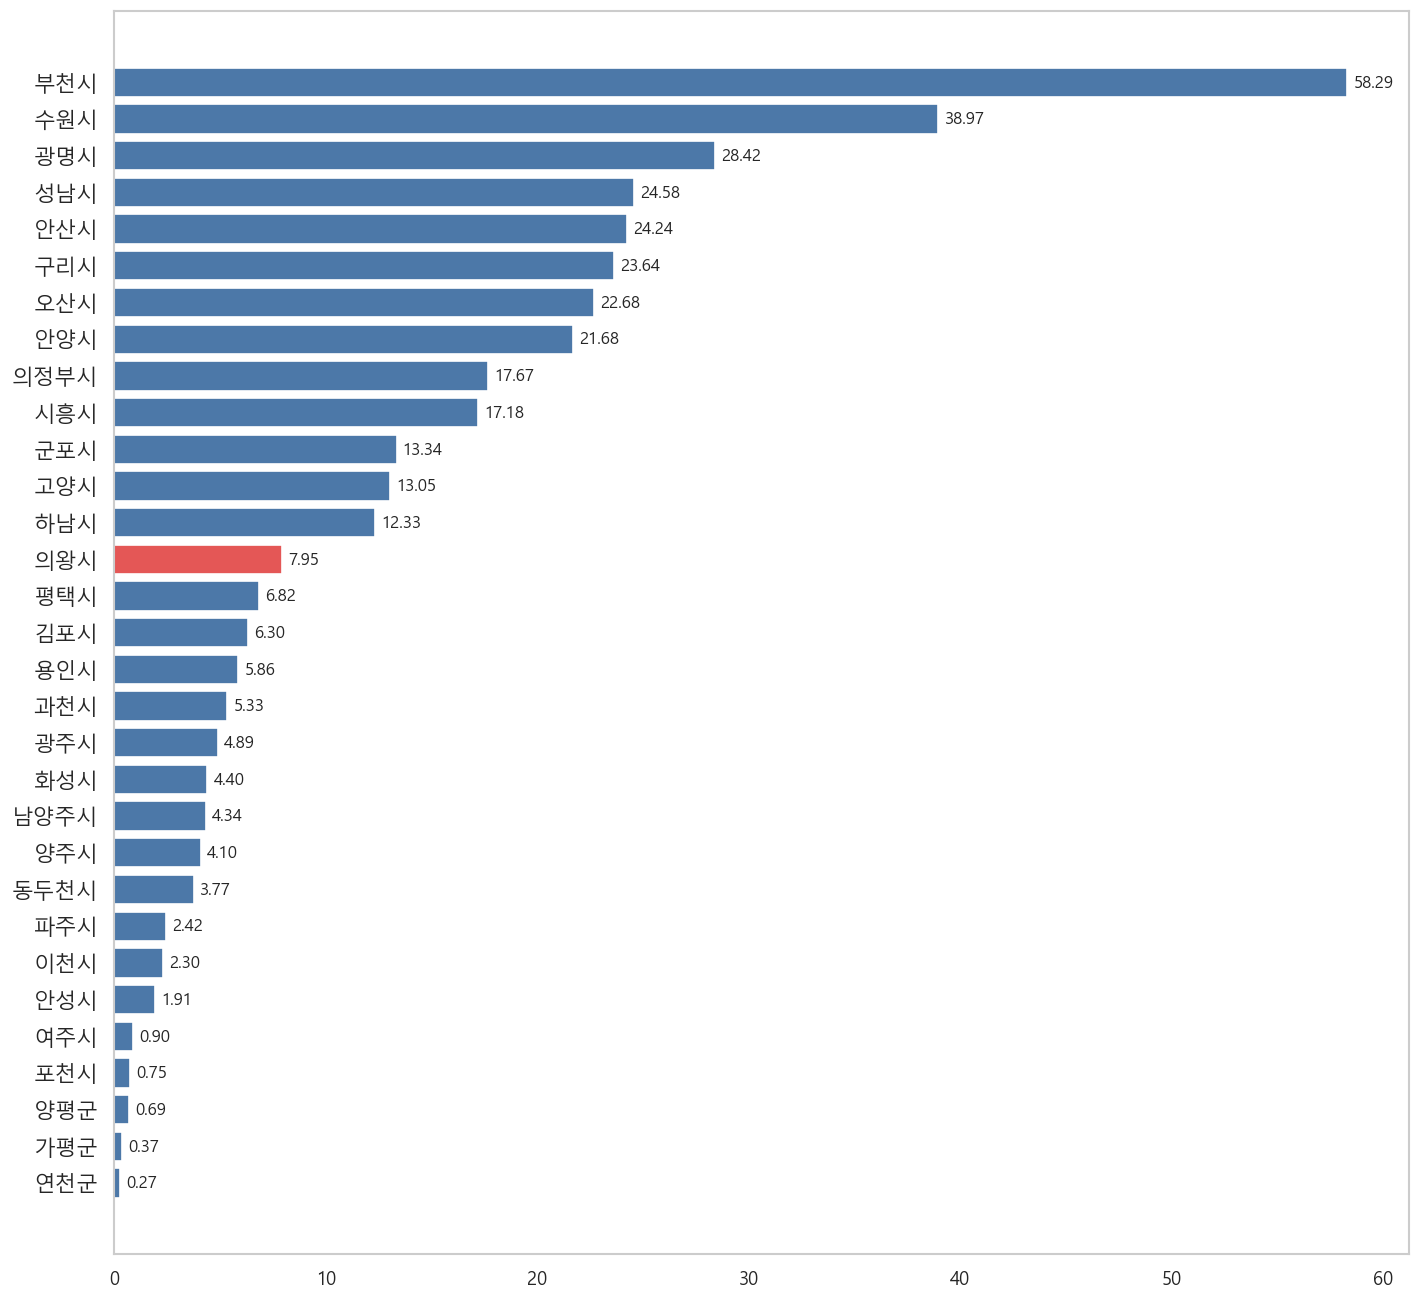

In [106]:
# 시각화 1-확장C: 경기 시군구 면적대비 사고(건/㎢) 순위
rank_area_acc = gyeonggi[['시군구', '사고_면적대비(건/㎢)']].dropna().copy()
rank_area_acc = rank_area_acc.sort_values('사고_면적대비(건/㎢)', ascending=True)

colors = ['#4C78A8' if x != '의왕시' else '#E45756' for x in rank_area_acc['시군구']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(rank_area_acc['시군구'], rank_area_acc['사고_면적대비(건/㎢)'], color=colors)
# ax.set_title('경기 시군구 면적대비 사고(건/㎢) 순위', fontsize=15, fontweight='bold')
# ax.set_xlabel('사고(건/㎢)', fontsize=13)
# ax.set_ylabel('시군구', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

for y, val in enumerate(rank_area_acc['사고_면적대비(건/㎢)']):
    ax.text(val + rank_area_acc['사고_면적대비(건/㎢)'].max() * 0.005, y, f'{val:.2f}', va='center', fontsize=10)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

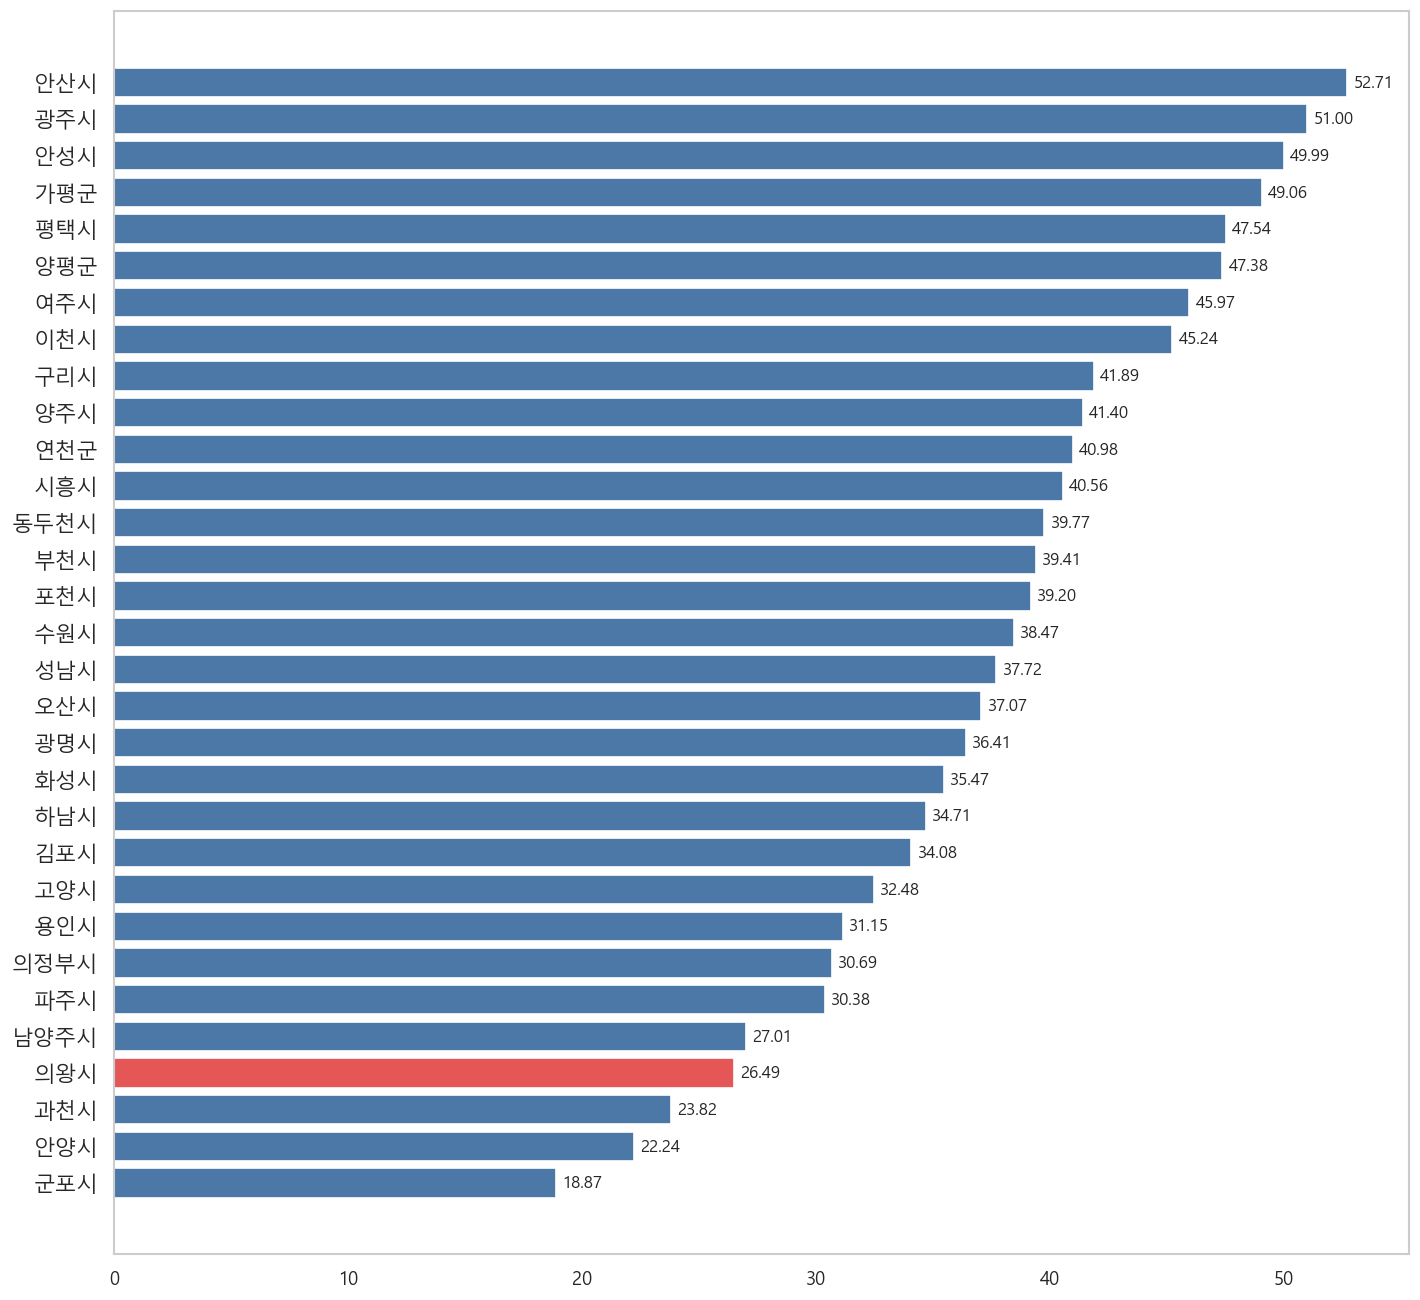

In [107]:
# 시각화 1-확장D: 경기 시군구 인구 1만명당 사고(건) 순위
rank_pop_acc = gyeonggi[['시군구', '사고_인구1만명당(건)']].dropna().copy()
rank_pop_acc = rank_pop_acc.sort_values('사고_인구1만명당(건)', ascending=True)

colors = ['#4C78A8' if x != '의왕시' else '#E45756' for x in rank_pop_acc['시군구']]

fig, ax = plt.subplots(figsize=(12, 11))
ax.barh(rank_pop_acc['시군구'], rank_pop_acc['사고_인구1만명당(건)'], color=colors)
# ax.set_title('경기 시군구 인구 1만명당 사고(건) 순위', fontsize=15, fontweight='bold')
# ax.set_xlabel('인구 1만명당 사고(건)', fontsize=13)
# ax.set_ylabel('시군구', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=11)
ax.grid(False)

for y, val in enumerate(rank_pop_acc['사고_인구1만명당(건)']):
    ax.text(val + rank_pop_acc['사고_인구1만명당(건)'].max() * 0.005, y, f'{val:.2f}', va='center', fontsize=10)

fix_korean_font(fig)
plt.tight_layout()
plt.show()

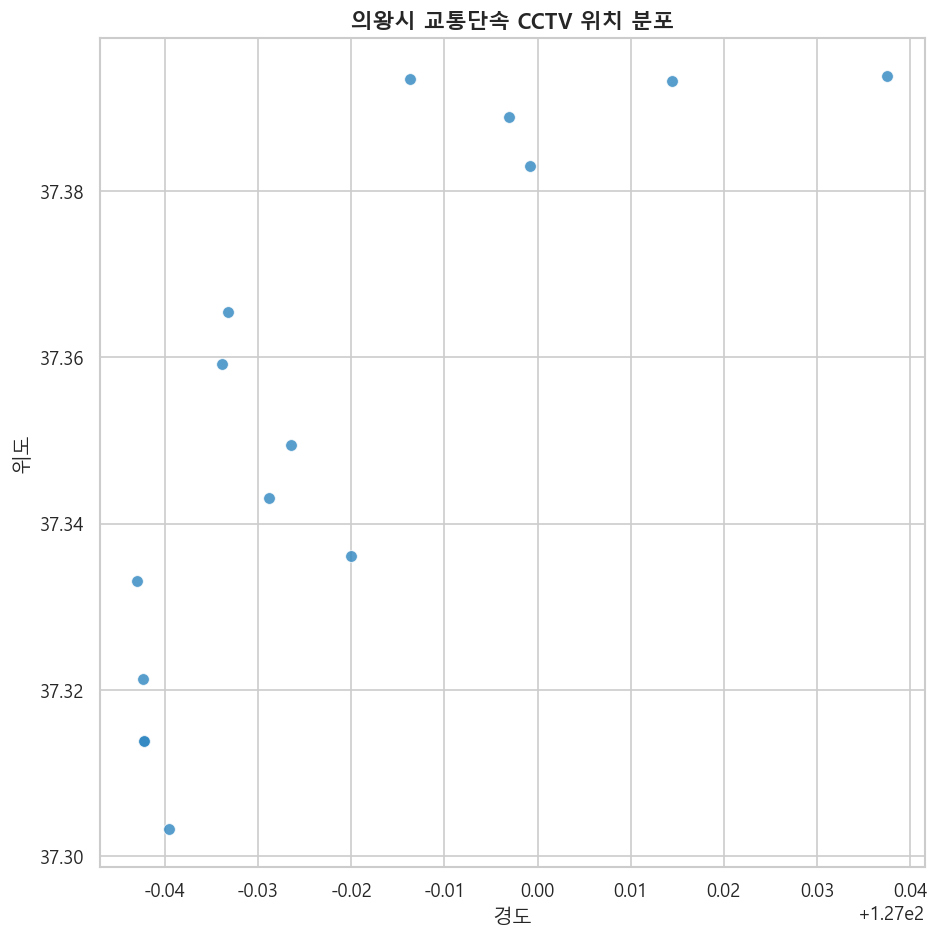

In [108]:
# 시각화 2: 교통단속 CCTV 위치 분포
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=traffic_cctv,
    x='경도',
    y='위도',
    s=50,
    alpha=0.8,
    color='#2E86C1',
    ax=ax
)
ax.set_title('의왕시 교통단속 CCTV 위치 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

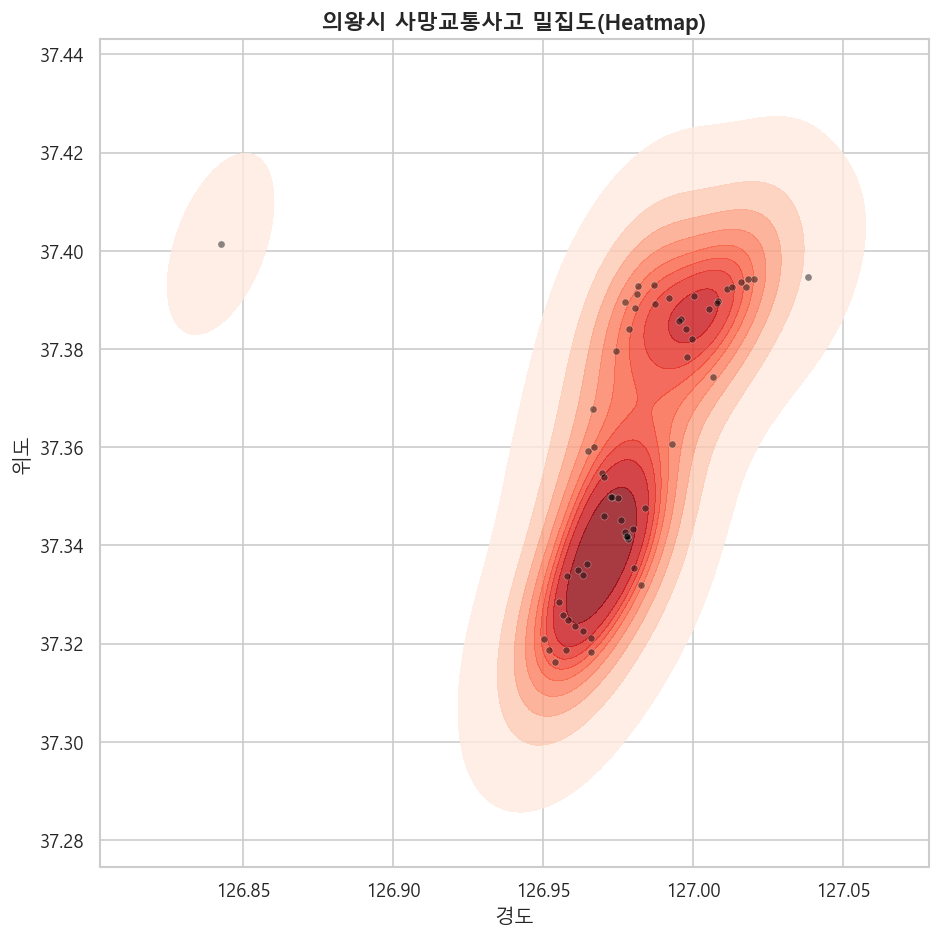

In [109]:
# 시각화 3: 의왕시 사망교통사고 밀집도(Heatmap)
fig, ax = plt.subplots(figsize=(8, 8))
sns.kdeplot(
    data=fatal,
    x='경도',
    y='위도',
    fill=True,
    cmap='Reds',
    levels=10,
    thresh=0.02,
    alpha=0.8,
    ax=ax
)
sns.scatterplot(
    data=fatal,
    x='경도',
    y='위도',
    s=18,
    color='black',
    alpha=0.45,
    ax=ax
)
ax.set_title('의왕시 사망교통사고 밀집도(Heatmap)', fontsize=13, fontweight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

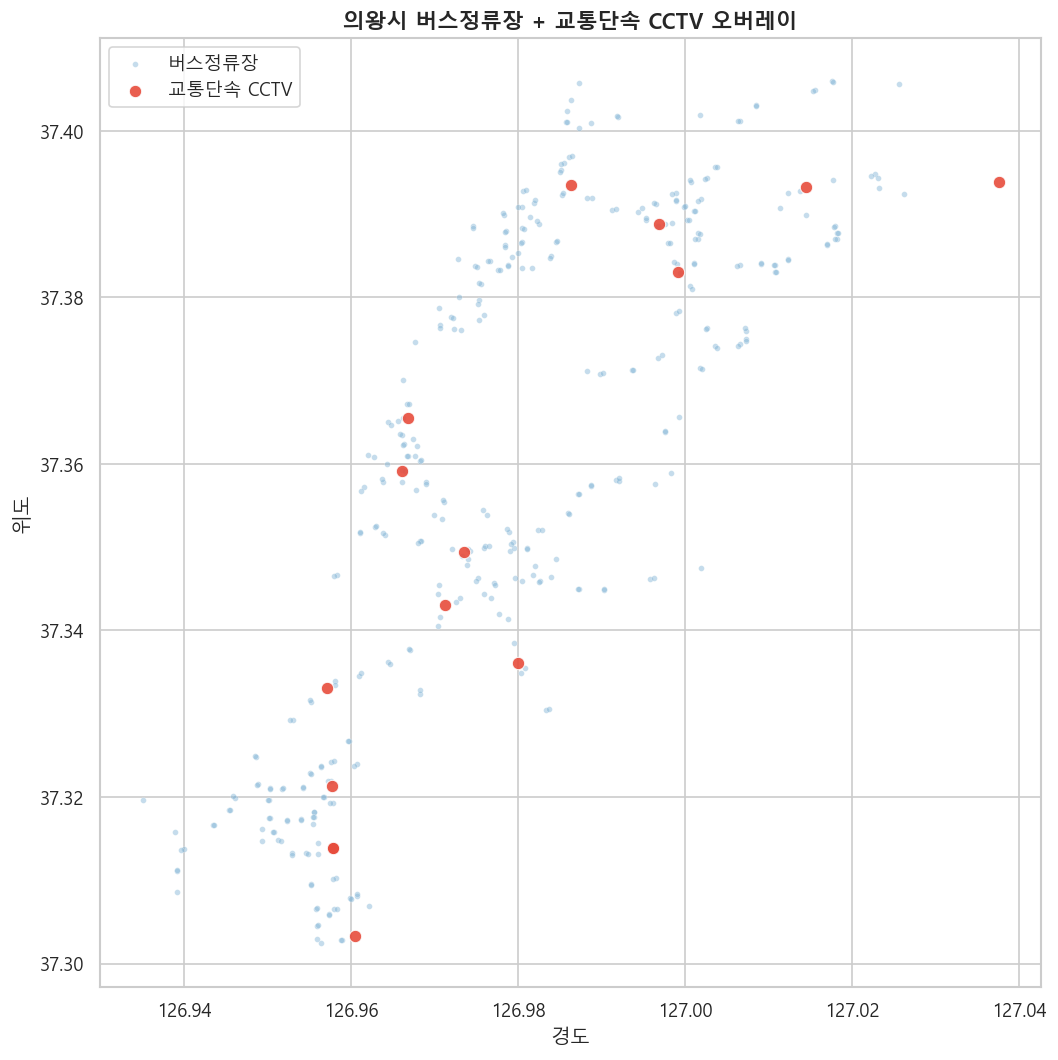

In [110]:
# 시각화 4: 버스정류장 + 교통단속 CCTV 오버레이
fig, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(
    data=bus_stop,
    x='경도',
    y='위도',
    s=12,
    alpha=0.45,
    color='#7FB3D5',
    label='버스정류장',
    ax=ax
)
sns.scatterplot(
    data=traffic_cctv,
    x='경도',
    y='위도',
    s=55,
    alpha=0.9,
    color='#E74C3C',
    label='교통단속 CCTV',
    ax=ax
)
ax.set_title('의왕시 버스정류장 + 교통단속 CCTV 오버레이', fontsize=13, fontweight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.legend(loc='best')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

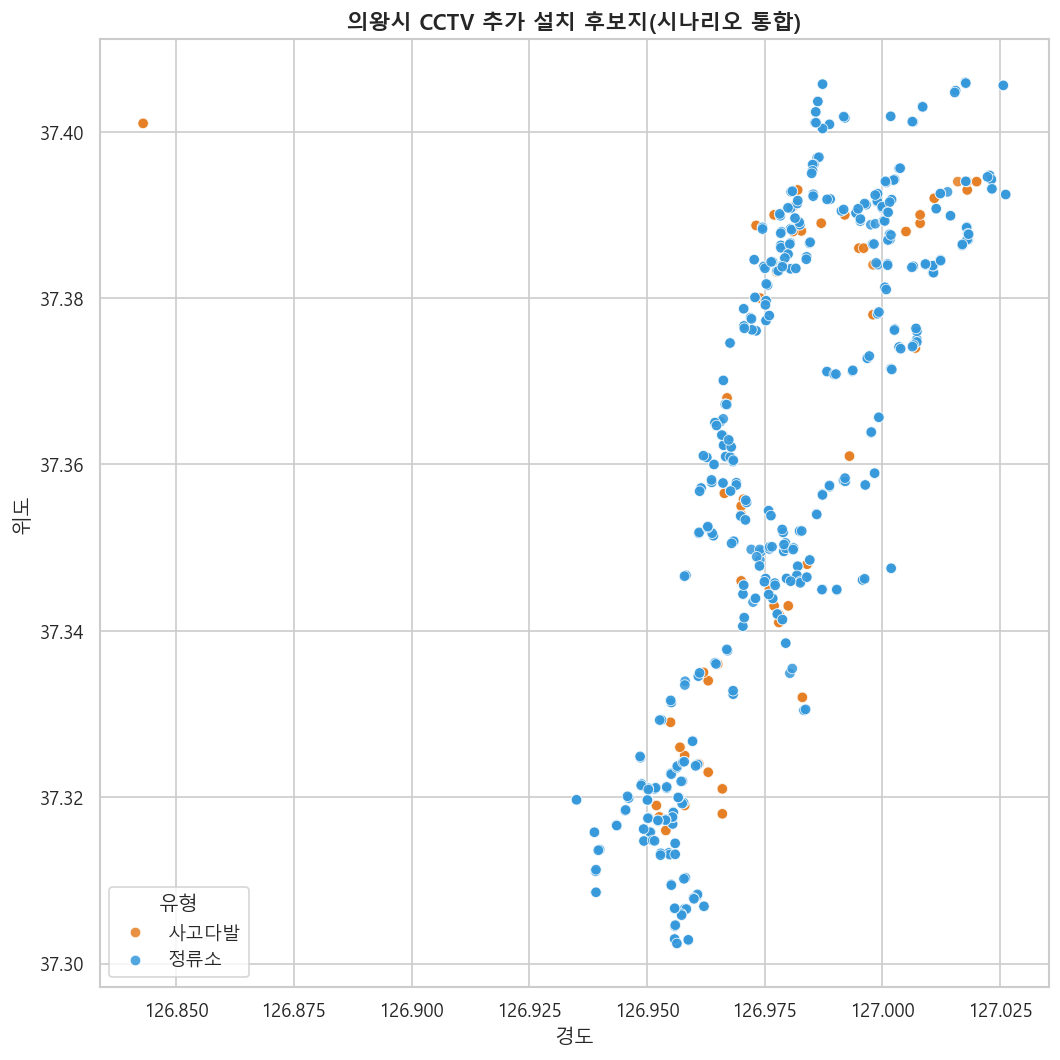

In [111]:
# 시각화 5: 최종 CCTV 추가 설치 후보지
plot_cand = candidates.copy()
plot_cand['유형'] = plot_cand['유형'].fillna('기타')

fig, ax = plt.subplots(figsize=(9, 9))
palette = {'사고다발': '#E67E22', '정류소': '#3498DB', '복합': '#8E44AD', '기타': '#95A5A6'}

sns.scatterplot(
    data=plot_cand,
    x='경도',
    y='위도',
    hue='유형',
    palette=palette,
    s=40,
    alpha=0.85,
    ax=ax
)

ax.set_title('의왕시 CCTV 추가 설치 후보지(시나리오 통합)', fontsize=13, fontweight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.legend(title='유형', loc='best')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

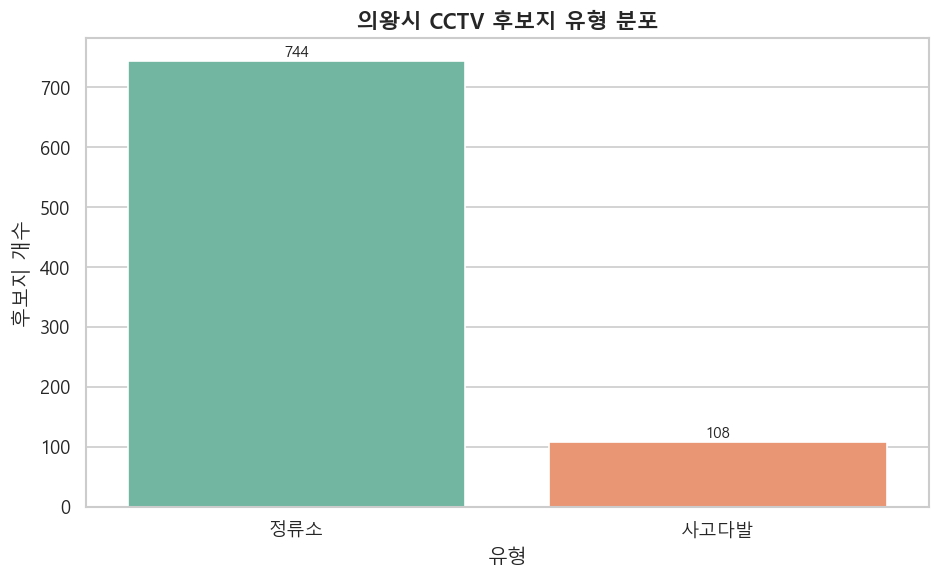

In [112]:
# 추가 시각화 1: CCTV 후보지 유형 분포
type_counts = (
    candidates['유형']
    .fillna('기타')
    .value_counts()
    .rename_axis('유형')
    .reset_index(name='개수')
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=type_counts,
    x='유형',
    y='개수',
    hue='유형',
    palette='Set2',
    legend=False,
    ax=ax,
    dodge=False,
 )
ax.set_title('의왕시 CCTV 후보지 유형 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('유형')
ax.set_ylabel('후보지 개수')
for i, v in enumerate(type_counts['개수']):
    ax.text(i, v + max(type_counts['개수']) * 0.01, f'{int(v)}', ha='center', fontsize=9)
fix_korean_font(fig)
plt.tight_layout()
plt.show()

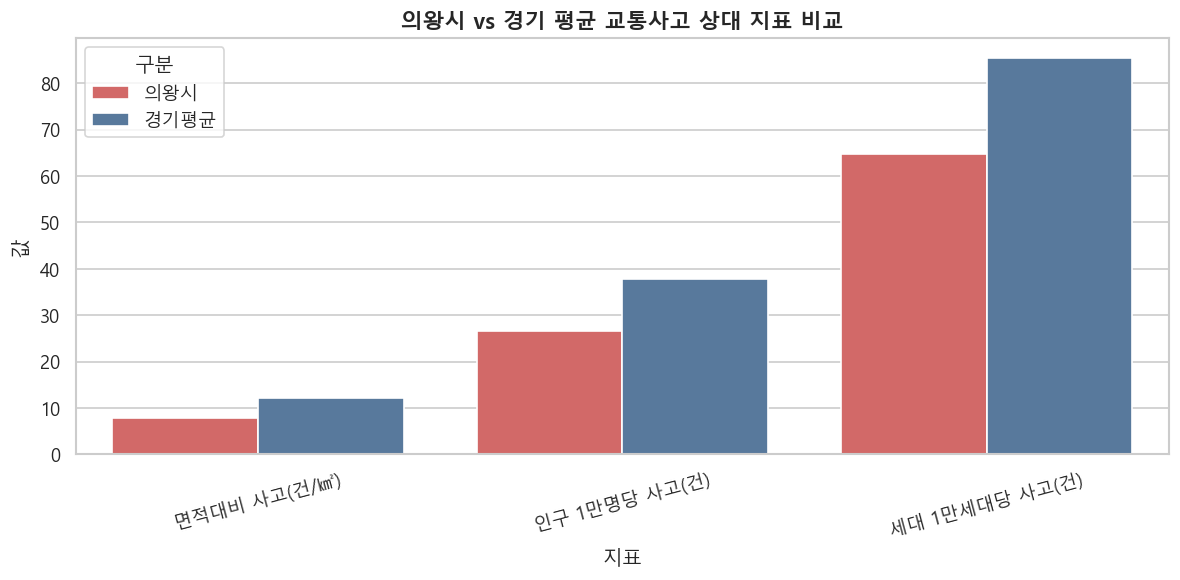

In [113]:
# 추가 시각화 2: 의왕시 vs 경기 평균(표준화 지표 비교)
metrics = [
    ('사고_면적대비(건/㎢)', '면적대비 사고(건/㎢)'),
    ('사고_인구1만명당(건)', '인구 1만명당 사고(건)'),
    ('사고_세대1만세대당(건)', '세대 1만세대당 사고(건)'),
]

g_mean = gyeonggi[[m[0] for m in metrics]].mean(numeric_only=True)
if uiwang_row.empty:
    raise ValueError('의왕시 행을 찾지 못했습니다. 데이터 파일을 확인하세요.')
u_val = uiwang_row.iloc[0][[m[0] for m in metrics]]

compare_df = pd.DataFrame({
    '지표': [m[1] for m in metrics],
    '의왕시': [float(u_val[m[0]]) for m in metrics],
    '경기평균': [float(g_mean[m[0]]) for m in metrics],
})

plot_df = compare_df.melt(id_vars='지표', var_name='구분', value_name='값')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x='지표', y='값', hue='구분', palette=['#E45756', '#4C78A8'], ax=ax)
ax.set_title('의왕시 vs 경기 평균 교통사고 상대 지표 비교', fontsize=13, fontweight='bold')
ax.set_xlabel('지표')
ax.set_ylabel('값')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='구분')
fix_korean_font(fig)
plt.tight_layout()
plt.show()

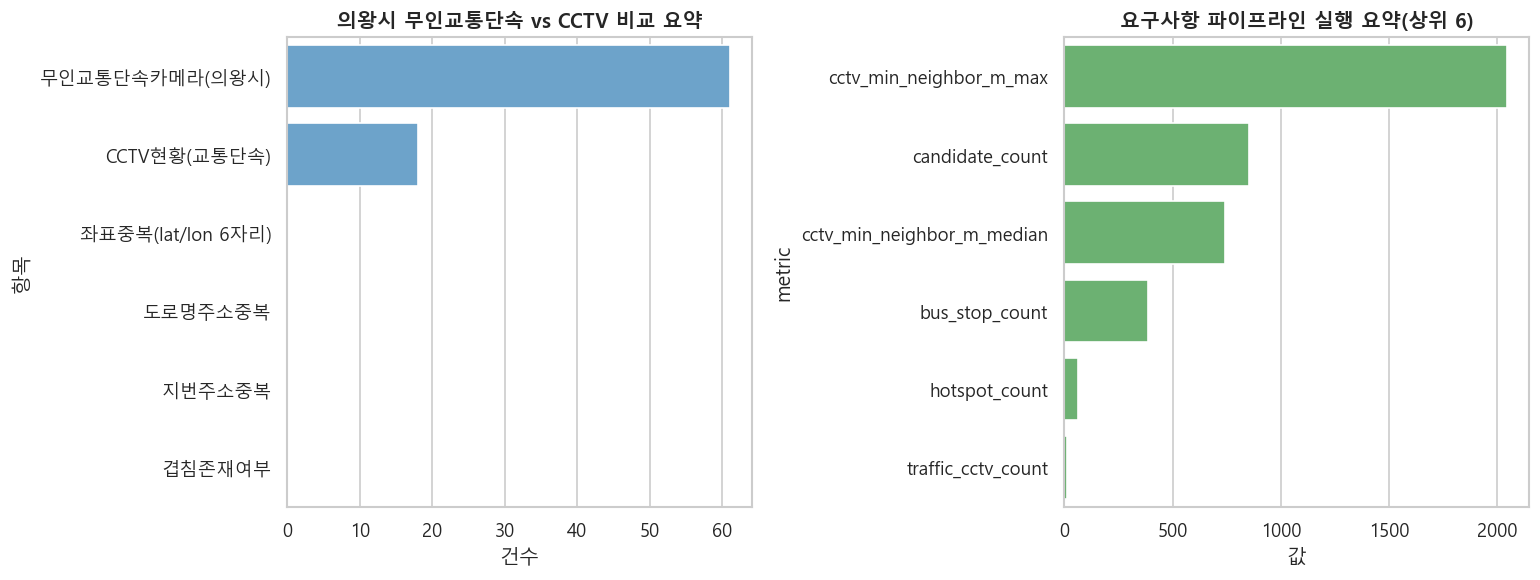

In [114]:
# 추가 시각화 3: 데이터 정합성/규모 요약
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 무인교통단속 vs CCTV 비교 요약
cmp_plot = comparison_summary.copy()
cmp_plot['건수'] = pd.to_numeric(cmp_plot['건수'], errors='coerce')
sns.barplot(data=cmp_plot, y='항목', x='건수', color='#5DA5DA', ax=axes[0])
axes[0].set_title('의왕시 무인교통단속 vs CCTV 비교 요약', fontsize=12, fontweight='bold')
axes[0].set_xlabel('건수')
axes[0].set_ylabel('항목')

# (우) 파이프라인 실행 요약 metric
run_plot = run_summary.copy()
run_plot['value'] = pd.to_numeric(run_plot['value'], errors='coerce')
top_metrics = run_plot.sort_values('value', ascending=False).head(6)
sns.barplot(data=top_metrics, y='metric', x='value', color='#60BD68', ax=axes[1])
axes[1].set_title('요구사항 파이프라인 실행 요약(상위 6)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('값')
axes[1].set_ylabel('metric')

fix_korean_font(fig)
plt.tight_layout()
plt.show()